In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False
import os 

from sklearn.metrics import normalized_mutual_info_score as NMI

## 挑选top gene 

使用104 summary结果

In [2]:
df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/paper_result/summary_df.csv', index_col=0)
gene_length = df['gene'].value_counts().to_dict()


##  df 根据 score 排序 
df = df.sort_values(by='score', ascending=False)
df.head(10)

# # 使用 groupby 和 agg 进行聚合
# new_df = df.groupby('gene')['score'].agg(['sum', 'mean']).reset_index()

# # 为了清晰，重命名列名
# new_df.columns = ['gene', 'score_sum', 'score_mean']

# # 按照 score_sum 降序排列，方便后续筛选高贡献基因
# new_df = new_df.sort_values(by='score_mean', ascending=False)

# print(new_df.head())

,NMI,Eco_Mode,gene,非洲兽目,鲸目,啮齿目,真盲缺目,翼手目,eco_cover,eco_cover_score,score
MRO_68,0.694043,M,MRO,0.0,0.8,1.0,1.0,1.0000,4,0.90,0.624639
SLC26A5_496,0.571984,M,SLC26A5,1.0,1.0,1.0,0.5,0.8750,5,1.00,0.571984
ZC3H3_249,0.625136,P,ZC3H3,1.0,0.9,0.0,0.5,0.8750,4,0.90,0.562623
CWF19L1_403,0.680895,I,CWF19L1,0.0,1.0,0.0,0.5,0.8750,3,0.75,0.510672
CCDC92_3,0.562802,A,CCDC92,1.0,0.9,1.0,0.0,0.6250,4,0.90,0.506522
SLC26A5_307,0.646038,S,SLC26A5,0.0,1.0,1.0,0.0,0.7500,3,0.75,0.484528
GLB1_334,0.467168,V,GLB1,1.0,0.9,1.0,0.5,1.0000,5,1.00,0.467168
ANXA1_211,0.512612,K,ANXA1,1.0,0.9,0.0,0.5,0.8750,4,0.90,0.461350
FOXK1_411,0.506884,S,FOXK1,1.0,0.9,0.0,0.5,0.9375,4,0.90,0.456195
NT5C1A_26,0.454639,H,NT5C1A,1.0,0.9,1.0,0.5,0.0625,5,1.00,0.454639


In [4]:
import pandas as pd

def aggregate_top_k(df, k=3):
    """
    df: 包含 gene 和 score 的原始数据
    k: 每个基因取前k个最高分
    """
    
    # 定义聚合逻辑
    def get_top_k_metrics(x):
        # 对该基因内部的 score 进行降序排列
        top_scores = x.sort_values(ascending=False).head(k)
        return pd.Series({
            f'top_{k}_sum': top_scores.sum(),
            f'top_{k}_mean': top_scores.mean(),
            'total_sites': len(x) # 顺便统计一下该基因贡献了多少个位点
        })

    # 分组计算
    new_df = df.groupby('gene')['score'].apply(get_top_k_metrics).unstack().reset_index()
    
    # 按照 top_k_sum 降序排列
    new_df = new_df.sort_values(by=f'top_{k}_sum', ascending=False)
    
    return new_df

k_df = aggregate_top_k(df, k=5)
k_df.head(20)

,gene,top_5_sum,top_5_mean,total_sites
562,SLC26A5,2.028060,0.405612,738.0
672,USP54,1.854482,0.370896,1679.0
266,GOLGA3,1.814420,0.362884,1494.0
460,PDZD2,1.790612,0.358122,2837.0
523,RMI1,1.782284,0.356457,625.0
96,CCDC92,1.780136,0.356027,314.0
609,TDRD7,1.768065,0.353613,1094.0
14,AHCTF1,1.763483,0.352697,2266.0
510,RAI1,1.757331,0.351466,1881.0
117,CEP97,1.749553,0.349911,846.0


In [7]:
gene_list = k_df.head(100)['gene'].tolist()
with open('top_gene.txt', 'w') as f:
    for ele in gene_list:
        f.write(ele + '\n')

### 通路富集

In [ ]:

import gseapy as gp
gene_list = k_df.head(100)['gene'].tolist()
description = 'Top 20 Mutations'
# gene_sets_list = [ 'Jensen_DISEASES_Curated_2025', 'Elsevier_Pathway_Collection', 'Reactome_Pathways_2024',
#               'KEGG_2026', 'GO_Biological_Process_2025', 'Orphanet_Augmented_2021', 'ClinVar_2025', 'Table_Mining_of_CRISPR_Studies',]

gene_sets_list = [  'Elsevier_Pathway_Collection', 'Reactome_Pathways_2024',
              'KEGG_2026', 'GO_Biological_Process_2025']

res = []
for gene_sets in gene_sets_list:
    enr = gp.enrichr(gene_list=gene_list,
                        gene_sets=gene_sets,
                        organism='Human', # 即使是蝙蝠/鲸，通常也比对到人类基因名进行分析
                        outdir=None,
                        cutoff=0.05
                    )
    results = enr.results

    sig_results = results.loc[results['Adjusted P-value'] < 0.05,]

    if sig_results.empty:
        print("没有发现显著富集的通路，请考虑扩大基因列表或检查基因名格式。")
    res.append(sig_results)
    

没有发现显著富集的通路，请考虑扩大基因列表或检查基因名格式。


In [26]:
# sel_term = []
# for ele in results['Term'].values:
#     if 'Tablesupplemental' in ele:
#         continue 
#     else:
#         sel_term.append(ele)
# print(len(sel_term))
# df = results.loc[results['Term'].isin(sel_term),:]

# for ele in sel_term:
#     print(ele)

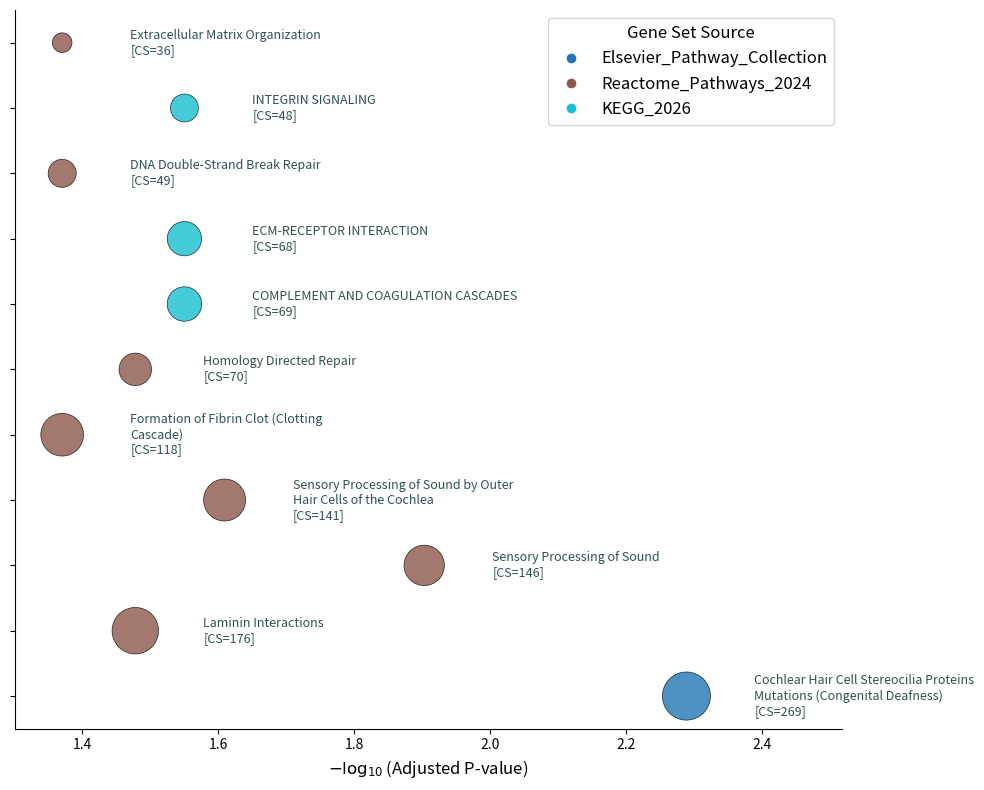

In [32]:

from matplotlib.colors import ListedColormap
import textwrap 

results = pd.concat(res)
df = results.copy()
def parse_overlap(s):
    if '/' in s:
        num, den = s.split('/')
        return int(num), int(den)
    return 0, 1

df[['Overlap_Num', 'Overlap_Den']] = df['Overlap'].apply(lambda x: pd.Series(parse_overlap(x)))

# 计算 -log10(Adjusted P-value)
df['NegLog10_AdjP'] = -np.log10(df['Adjusted P-value'])

# 规范化 Odds Ratio 用于气泡大小（避免过大差异）
df['OR_scaled'] = np.log10(df['Odds Ratio'])  # 对数缩放更合理
df['Bubble_Size'] = (df['OR_scaled'] - df['OR_scaled'].min()) / (df['OR_scaled'].max() - df['OR_scaled'].min()) * 1000 + 200  # 映射到 200~1200

# 按 Combined Score 降序排列（主排序）
df = df.sort_values('Combined Score', ascending=False).reset_index(drop=True)

# 为 Gene_set 创建颜色映射
gene_sets = df['Gene_set'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(gene_sets)))
color_map = {gs: colors[i] for i, gs in enumerate(gene_sets)}

df['Color'] = df['Gene_set'].map(color_map)

# ==============================
# Step 2: 绘图
# ==============================
plt.figure(figsize=(10, 8))
ax = plt.gca()

# 绘制气泡
scatter = ax.scatter(
    df['NegLog10_AdjP'],
    range(len(df)),
    s=df['Bubble_Size'],
    c=df['Color'],
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5,
    zorder=3
)

# 添加通路标签（右侧）—— 支持自动换行
for i, (term, cs) in enumerate(zip(df['Term'], df['Combined Score'])):
    # 使用 textwrap 将长文本按字符数拆分为最多2行（每行约30个字符）
    wrapped = textwrap.fill(term, width=40, max_lines=2, placeholder="...")
    label_text = f"{wrapped}\n[CS={cs:.0f}]"
    
    ax.text(
        df['NegLog10_AdjP'].iloc[i] + 0.1,
        i,
        label_text,
        va='center',
        fontsize=9,
        fontweight='regular',
        color='darkslategray',
        linespacing=1.2  # 控制行间距
    )




# 设置 Y 轴：通路名（左侧，不重复显示）
ax.set_yticks(range(len(df)))
ax.set_yticklabels([])  # 隐藏默认 yticklabels，用 text 代替

# X 轴：-log10(Adj P)
ax.set_xlabel(r'$-\log_{10}$(Adjusted P-value)', fontsize=12)
ax.set_xlim(left=-np.log10(0.05), right=df['NegLog10_AdjP'].max() * 1.1)

# # 添加显著性阈值线（FDR < 0.05 → -log10(0.05) ≈ 1.3010）
# ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=1, alpha=0.7)
# ax.text(-np.log10(0.05)+0.05, len(df)-0.5, 'FDR=0.05', color='red', fontsize=9, ha='left')

# 图例：Gene_set 分组
handles = [plt.Line2D([0], [0], marker='o', color='w', label=gs,
                      markerfacecolor=color_map[gs], markersize=8) 
           for gs in gene_sets]
ax.legend(handles=handles, loc='upper right', title='Gene Set Source', fontsize=12, title_fontsize=12)

# # 标题
# plt.title('Functional Enrichment Analysis: Top Terms by Combined Score', 
#           fontsize=14, fontweight='bold', pad=20)

# 美化
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# 保存（可选）
# plt.savefig("enrichment_bubble_plot.png", dpi=300, bbox_inches='tight')
plt.grid(False)
plt.show()

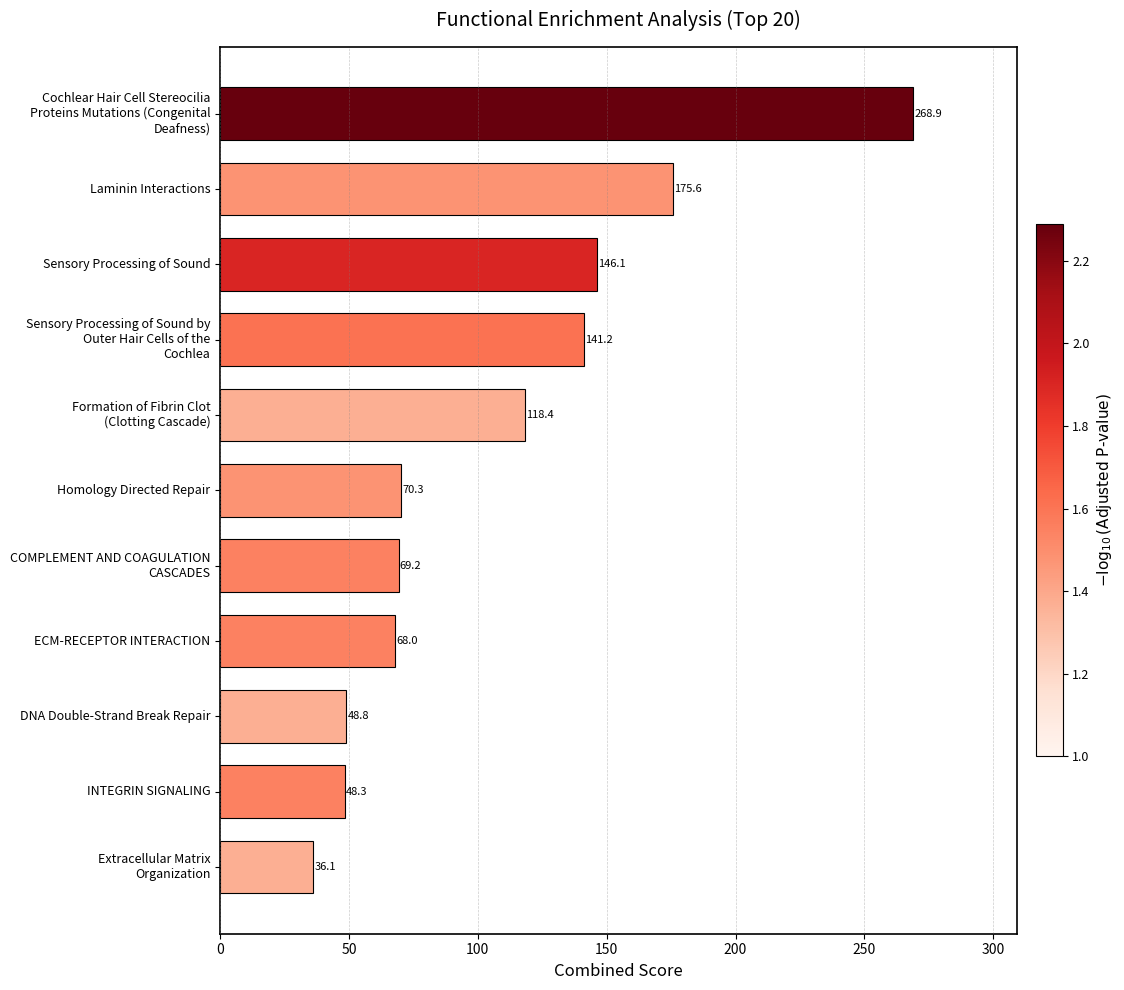

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import textwrap 

results = pd.concat(res)
df = results.copy()

def parse_overlap(s):
    if '/' in s:
        num, den = s.split('/')
        return int(num), int(den)
    return 0, 1

df[['Overlap_Num', 'Overlap_Den']] = df['Overlap'].apply(lambda x: pd.Series(parse_overlap(x)))

# 计算 -log10(Adjusted P-value)
df['NegLog10_AdjP'] = -np.log10(df['Adjusted P-value'])

# 按 Combined Score 降序排列（只取前20个，避免过多）
df = df.sort_values('Combined Score', ascending=True).reset_index(drop=True)
df = df.tail(20)  # 取前20个

# ==============================
# Step 2: 绘图（柱状图版）
# ==============================
fig, ax = plt.subplots(figsize=(12, 10))

# 创建颜色映射：根据 -log10(Adj P) 设置颜色深浅
# norm = Normalize(vmin=df['NegLog10_AdjP'].min(), vmax=df['NegLog10_AdjP'].max())
# cmap = plt.cm.Reds  # 使用红色渐变，越深表示越显著
norm = Normalize(1, vmax=df['NegLog10_AdjP'].max())
cmap = plt.cm.Reds
# 绘制水平柱状图
bars = ax.barh(
    range(len(df)),
    df['Combined Score'],
    color=cmap(norm(df['NegLog10_AdjP'])),
    edgecolor='black',
    linewidth=0.8,
    height=0.7
)

# 添加通路标签（Y轴）
y_labels = []
for term, overlap in zip(df['Term'], df['Overlap']):
    wrapped = textwrap.fill(term, width=30, max_lines=3, placeholder="...")
    # label = f"{wrapped} [{overlap}]"
    label = wrapped
    y_labels.append(label)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(y_labels, fontsize=9, va='center')

# X轴标签
ax.set_xlabel('Combined Score', fontsize=12, fontweight='bold')
ax.set_xlim(left=0, right=df['Combined Score'].max() * 1.15)

# 在柱状图上添加数值标签
for i, (cs, neglogp) in enumerate(zip(df['Combined Score'], df['NegLog10_AdjP'])):
    ax.text(
        cs + 0.5,
        i,
        f'{cs:.1f}',
        va='center',
        ha='left',
        fontsize=8,
        color='black',
        fontweight='bold'
    )

# 添加 colorbar（-log10(Adj P)）
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label(r'$-\log_{10}(\mathrm{Adjusted~P\text{-}value})$', fontsize=11, fontweight='bold')
cbar.ax.tick_params(labelsize=9)


# 美化
ax.grid(axis='x', linestyle='--', alpha=0.4, color='gray', linewidth=0.5)
ax.set_axisbelow(False)

# 设置边框
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('black')

# 标题
plt.title('Functional Enrichment Analysis (Top 20)', 
          fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()

# 保存
plt.savefig("enrichment_bar_plot.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.savefig("enrichment_bar_plot.png", dpi=300, bbox_inches='tight')

plt.show()

### 基因 位点 调控分数分布图

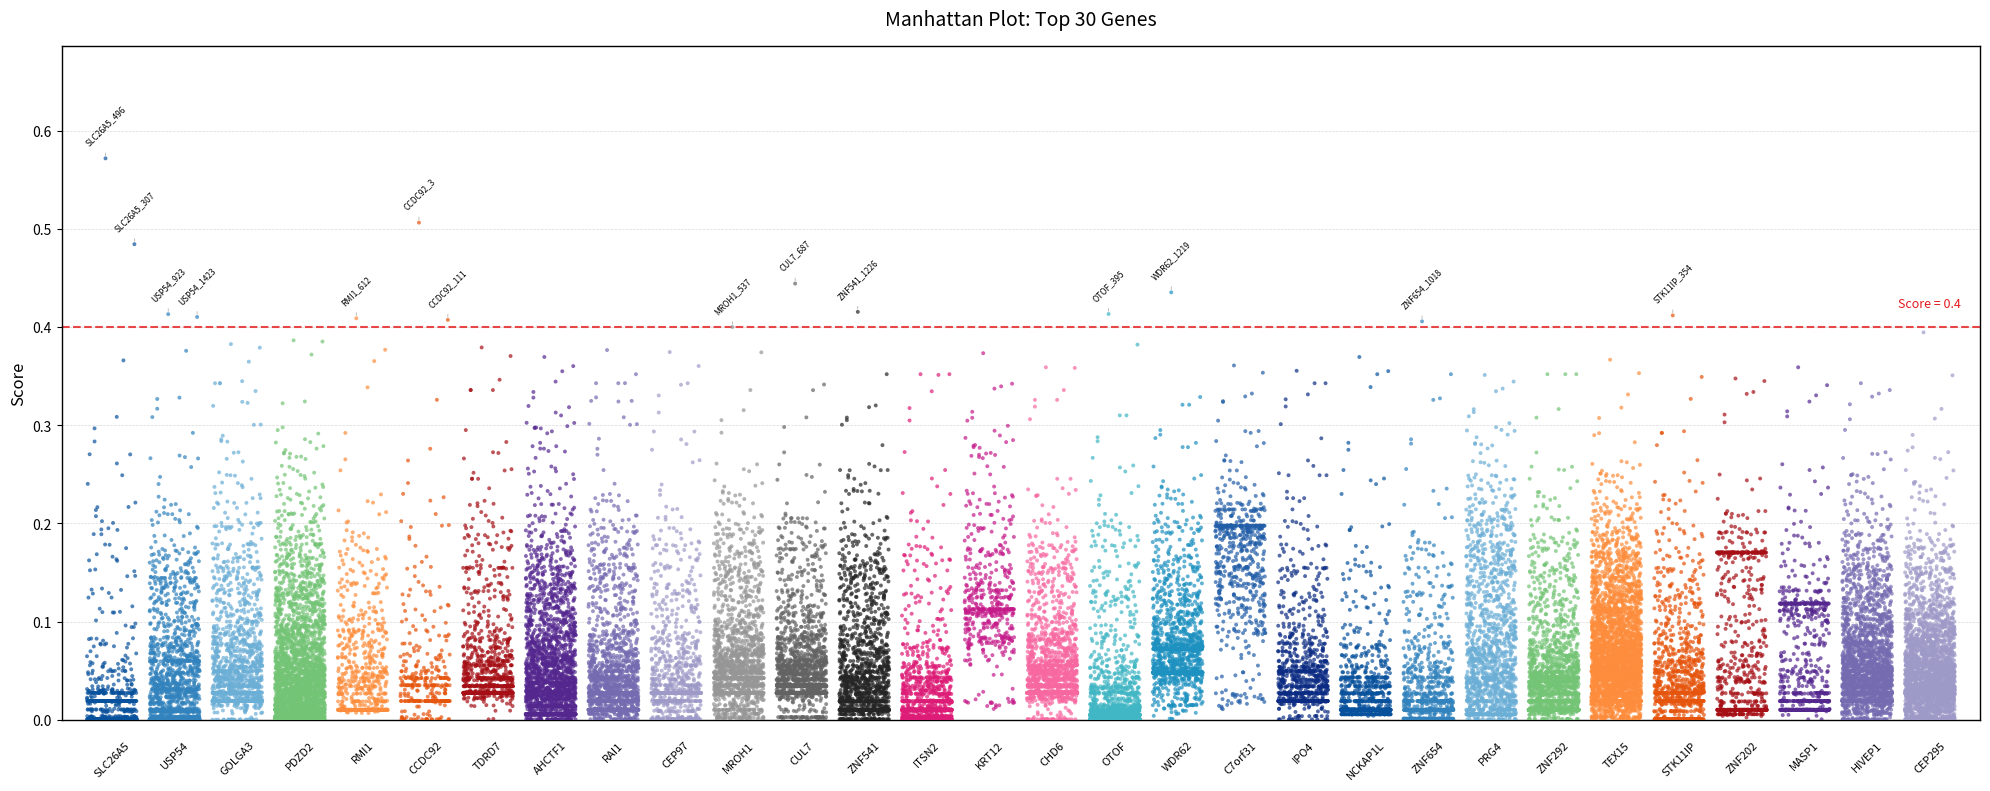

In [3]:
df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/paper_result/summary_df.csv', index_col=0)
gene_length = df['gene'].value_counts().to_dict()


##  df 根据 score 排序 
df = df.sort_values(by='score', ascending=False)
df.head(10)

import pandas as pd

def aggregate_top_k(df, k=3):
    """
    df: 包含 gene 和 score 的原始数据
    k: 每个基因取前k个最高分
    """
    
    # 定义聚合逻辑
    def get_top_k_metrics(x):
        # 对该基因内部的 score 进行降序排列
        top_scores = x.sort_values(ascending=False).head(k)
        return pd.Series({
            f'top_{k}_sum': top_scores.sum(),
            f'top_{k}_mean': top_scores.mean(),
            'total_sites': len(x) # 顺便统计一下该基因贡献了多少个位点
        })

    # 分组计算
    new_df = df.groupby('gene')['score'].apply(get_top_k_metrics).unstack().reset_index()
    
    # 按照 top_k_sum 降序排列
    new_df = new_df.sort_values(by=f'top_{k}_sum', ascending=False)
    
    return new_df

k_df = aggregate_top_k(df, k=5)

gene_list = k_df['gene'][:30].values 

## 绘制 GWAS 风格的曼哈顿图（带阈值标注版）

df_top20 = df[df['gene'].isin(gene_list)].copy()
gene_positions = {gene: i for i, gene in enumerate(gene_list)}

# CNS期刊常用配色方案
cns_colors = [
    '#08519c', '#3182bd', '#6baed6', '#74c476', '#fd8d3c',
    '#e6550d', '#a50f15', '#54278f', '#756bb1', '#9e9ac8',
    '#969696', '#636363', '#252525', '#dd1c77', '#c51b8a',
    '#f768a1', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84',
]

fig, ax = plt.subplots(figsize=(20, 8))

threshold = 0.40  # 设置阈值

for i, gene in enumerate(gene_list):
    gene_data = df_top20[df_top20['gene'] == gene].copy()
    gene_data = gene_data.sort_values('score', ascending=False)
    
    n_points = len(gene_data)
    
    # 使用随机 jitter
    np.random.seed(42)
    x_jitter = np.random.uniform(-0.4, 0.4, n_points)
    x_positions = i + x_jitter
    
    y_scores = gene_data['score'].values
    
    # 使用CNS配色
    color = cns_colors[i % len(cns_colors)]
    
    # 绘制散点
    ax.scatter(
        x_positions,
        y_scores,
        c=color,
        s=8,
        alpha=0.7,
        edgecolors='none',
        zorder=3
    )
    
    # 对超过阈值的点添加标注
    for j, (x_pos, y_score, idx) in enumerate(zip(x_positions, y_scores, gene_data.index)):
        if y_score > threshold:
            ax.annotate(
                idx,  # 突变名称
                xy=(x_pos, y_score),
                xytext=(0, 8),  # 向上偏移
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=45,
                color='black',
                fontweight='bold',
                arrowprops=dict(
                    arrowstyle='-',
                    color='gray',
                    lw=0.5,
                    alpha=0.7
                ),
                zorder=4
            )
    
    # 基因名称标注在X轴下方
    ax.text(
        i,
        -0.03,
        gene,
        ha='center',
        va='top',
        fontsize=8,
        rotation=45,
        transform=ax.get_xaxis_transform()
    )

# 设置x轴
ax.set_xlim(-0.8, len(gene_list) - 0.2)
ax.set_xticks([])

# 设置y轴
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_ylim(0, df_top20['score'].max() * 1.2)  # 增加顶部空间用于标注

# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray', linewidth=0.5)
ax.set_axisbelow(True)

# 添加阈值线
ax.axhline(y=threshold, color='#e41a1c', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(len(gene_list) - 0.5, threshold + 0.02, f'Score = {threshold}', 
        color='#e41a1c', fontsize=9, ha='right', fontweight='bold')

# 美化边框
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# 标题
plt.title('Manhattan Plot: Top 30 Genes', 
          fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()

# 保存
plt.savefig("manhattan_plot_annotated.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.savefig("manhattan_plot_annotated.png", dpi=300, bbox_inches='tight')

plt.show()